<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/DeepLearning/9_pytorch_basics_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons, make_circles

torch.manual_seed(0)
np.random.seed(0)

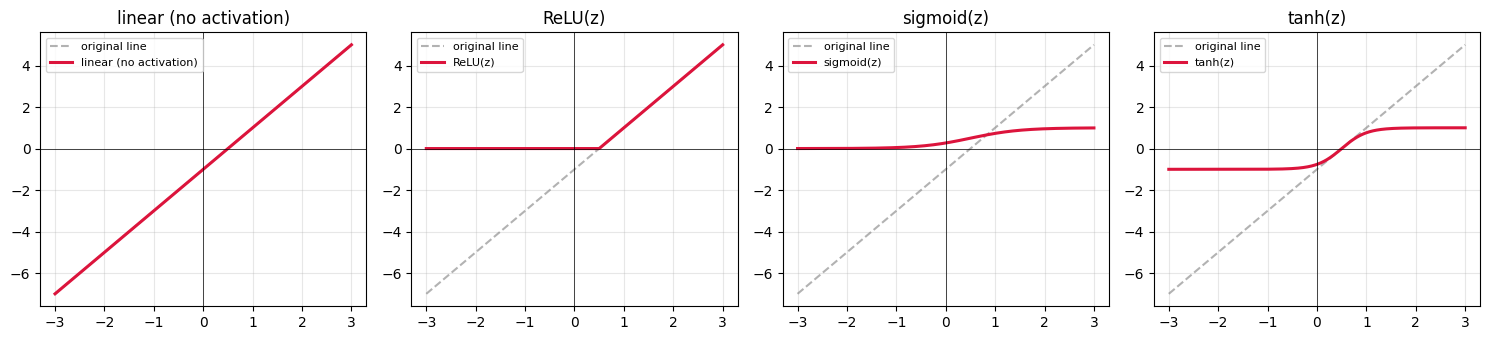

In [ ]:
x = np.linspace(-3, 3, 400)
z = 2 * x - 1                              # the "line" a neuron computes

activations = {
    "linear (no activation)": z,
    "ReLU(z)":    np.maximum(0, z),
    "sigmoid(z)": 1 / (1 + np.exp(-z)),
    "tanh(z)":    np.tanh(z),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, z, '--', color='gray', alpha=0.6, label='original line')
    ax.plot(x, y, color='crimson', linewidth=2.2, label=name)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(name); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

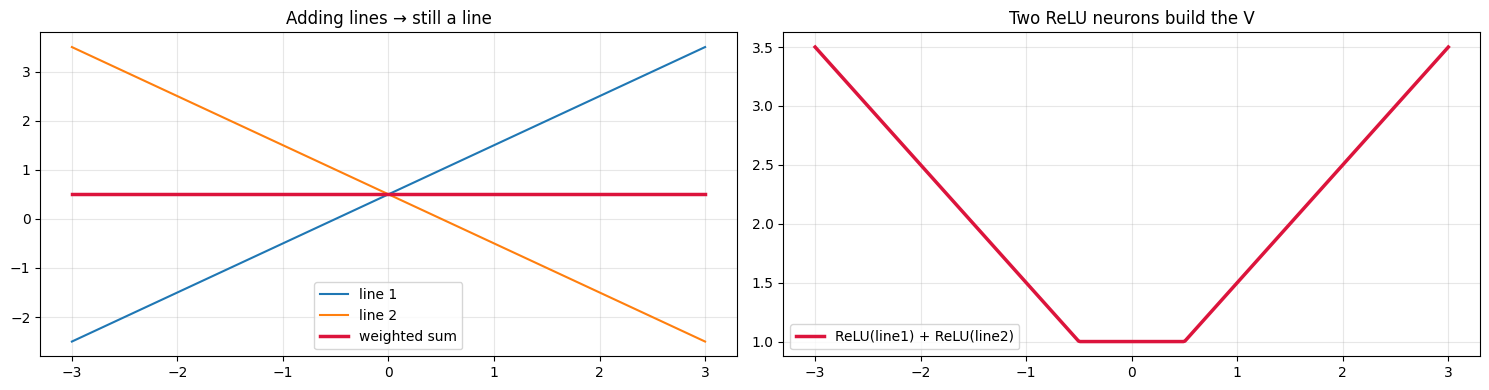

In [ ]:
x = np.linspace(-3, 3, 400)
line1 =  1.0 * x + 0.5
line2 = -1.0 * x + 0.5

weighted_sum = 0.5 * line1 + 0.5 * line2   # what a neural net layer can do
via_relu     = np.maximum(0, line1) + np.maximum(0, line2)  # two ReLU neurons!

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(x, line1, label='line 1'); axes[0].plot(x, line2, label='line 2')
axes[0].plot(x, weighted_sum, color='crimson', linewidth=2.5, label='weighted sum')
axes[0].set_title("Adding lines → still a line"); axes[0].legend(); axes[0].grid(alpha=0.3)


axes[1].plot(x, via_relu, color='crimson', linewidth=2.5, label='ReLU(line1) + ReLU(line2)')
axes[1].set_title("Two ReLU neurons build the V"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

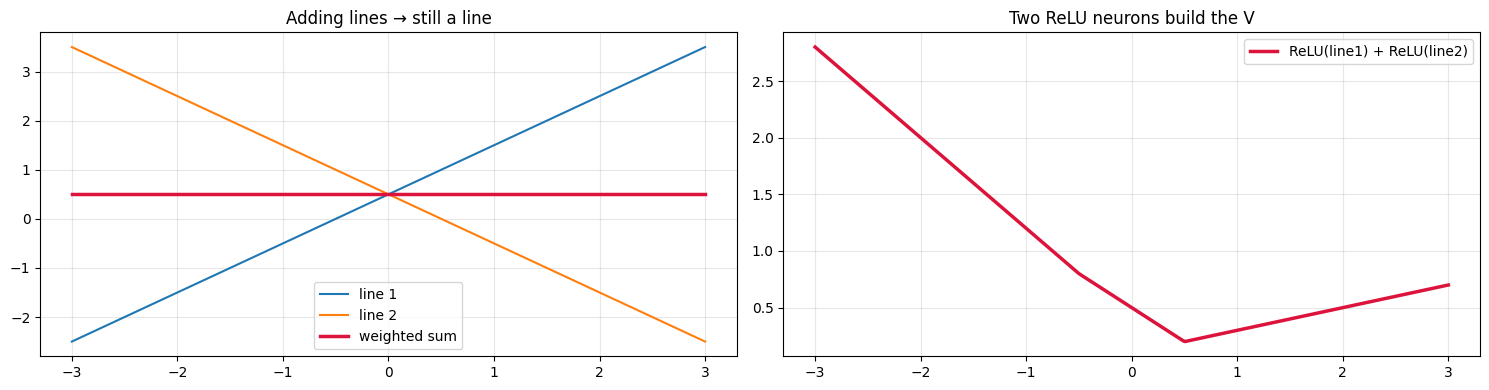

In [ ]:
x = np.linspace(-3, 3, 400)
line1 =  1.0 * x + 0.5
line2 = -1.0 * x + 0.5

weighted_sum = 0.5 * line1 + 0.5 * line2   # what a neural net layer can do
via_relu     = 0.2 * np.maximum(0, line1) + 0.8 * np.maximum(0, line2)  # two ReLU neurons!

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(x, line1, label='line 1'); axes[0].plot(x, line2, label='line 2')
axes[0].plot(x, weighted_sum, color='crimson', linewidth=2.5, label='weighted sum')
axes[0].set_title("Adding lines → still a line"); axes[0].legend(); axes[0].grid(alpha=0.3)


axes[1].plot(x, via_relu, color='crimson', linewidth=2.5, label='ReLU(line1) + ReLU(line2)')
axes[1].set_title("Two ReLU neurons build the V"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

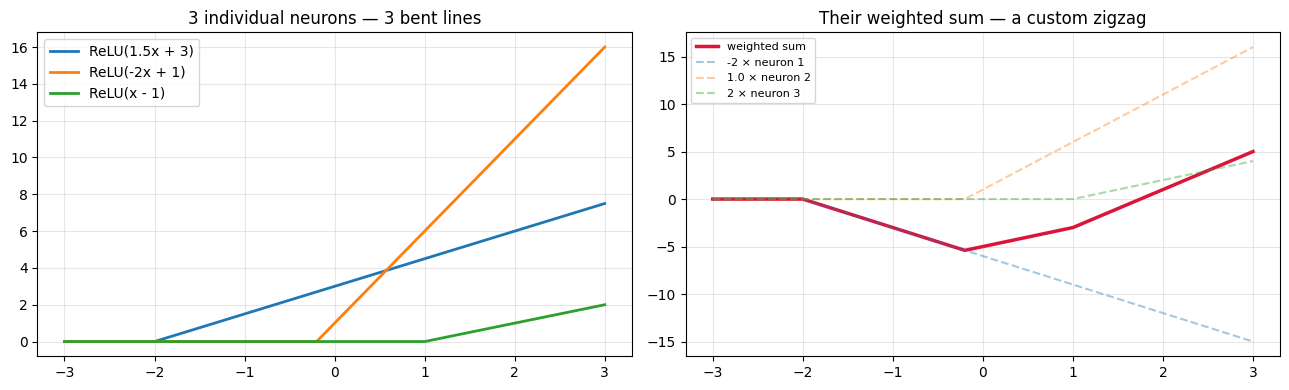

In [ ]:
x = np.linspace(-3, 3, 400)

# Three ReLU neurons, each with its own (w, b). Each bends at a different place.
n1 = np.maximum(0,  1.5 * x + 3.0)     # bends at x = -2,  slope +1.5
n2 = np.maximum(0, 5.0 * x + 1.0)     # bends at x = 0.5, slope -2.0 (flips direction)
n3 = np.maximum(0,  1.0 * x - 1.0)     # bends at x = 1,   slope +1.0

# Output-layer weights — how much of each bent line we mix in
#v1, v2, v3 = 1.0, 1.0, -1.5
v1 = -2; v2 = 1.0; v3 = 2
combined = v1 * n1 + v2 * n2 + v3 * n3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LEFT: each neuron's individual bent line
axes[0].plot(x, n1, label='ReLU(1.5x + 3)',  linewidth=2)
axes[0].plot(x, n2, label='ReLU(-2x + 1)',   linewidth=2)
axes[0].plot(x, n3, label='ReLU(x - 1)',     linewidth=2)
axes[0].set_title("3 individual neurons — 3 bent lines")
axes[0].grid(alpha=0.3); axes[0].legend()

# RIGHT: the weighted sum
axes[1].plot(x, combined, color='crimson', linewidth=2.5, label='weighted sum')
axes[1].plot(x, n1 * v1, '--', alpha=0.4, label=f'{v1} × neuron 1')
axes[1].plot(x, n2 * v2, '--', alpha=0.4, label=f'{v2} × neuron 2')
axes[1].plot(x, n3 * v3, '--', alpha=0.4, label=f'{v3} × neuron 3')
axes[1].set_title("Their weighted sum — a custom zigzag")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [ ]:
# Target: sin(x) on [-pi, pi]
x_data = torch.linspace(-np.pi, np.pi, 200).unsqueeze(1)
y_data = torch.sin(x_data)

def fit_sin_with_n_neurons(n_hidden, steps=3000):
    torch.manual_seed(3)
    model = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        loss = ((model(x_data) - y_data) ** 2).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x_data).squeeze().numpy()

        # print weights for each neuron in the 3-neuron example
    #print("Neuron 1 weights:", model[0].weight[0].item(), model[0].bias[0].item())
    #print("Neuron 2 weights:", model[0].weight[1].item(), model[0].bias[1].item())
    #print("Neuron 3 weights:", model[0].weight[2].item(), model[0].bias[2].item())

# Fit with 1, 3, 10, 50 hidden neurons
widths = [1, 3, 10, 50]
predictions = {n: fit_sin_with_n_neurons(n) for n in widths}

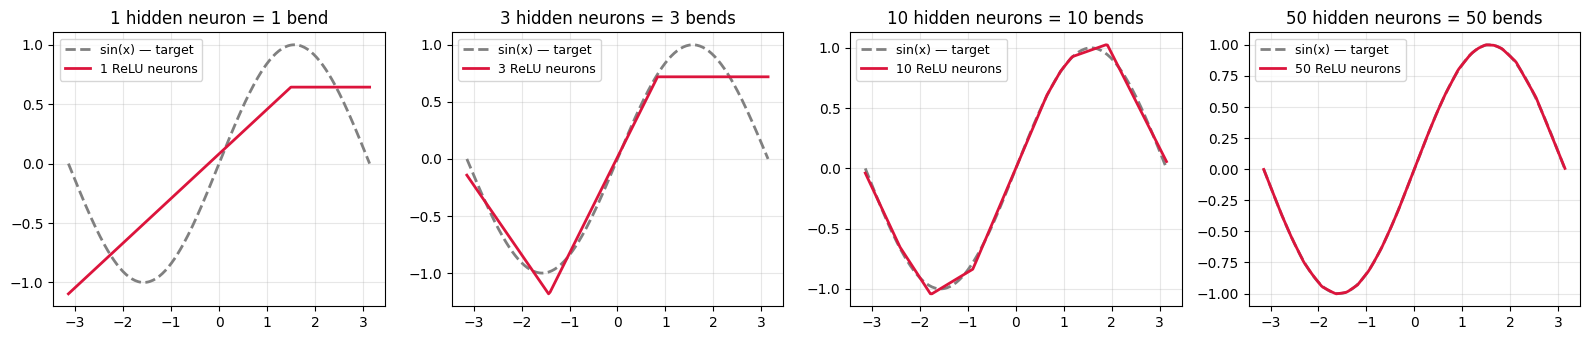

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, n in zip(axes, widths):
    ax.plot(x_data.squeeze(), y_data.squeeze(), '--', color='gray',
            linewidth=2, label='sin(x) — target')
    ax.plot(x_data.squeeze(), predictions[n], color='crimson',
            linewidth=2, label=f'{n} ReLU neurons')
    ax.set_title(f"{n} hidden neuron{'s' if n > 1 else ''} = {n} bend{'s' if n > 1 else ''}")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Break Equation Down!!

In [ ]:
# Target: sin(x) on [-pi, pi]
x_data = torch.linspace(-np.pi, np.pi, 200).unsqueeze(1)
y_data = torch.sin(x_data)


x_data.shape

torch.Size([200, 1])

In [ ]:

def fit_sin_with_n_neurons(n_hidden, steps=3000):
    torch.manual_seed(3)
    model = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        loss = ((model(x_data) - y_data) ** 2).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x_data).squeeze().numpy()

        # print weights for each neuron in the 3-neuron example
    #print("Neuron 1 weights:", model[0].weight[0].item(), model[0].bias[0].item())
    #print("Neuron 2 weights:", model[0].weight[1].item(), model[0].bias[1].item())
    #print("Neuron 3 weights:", model[0].weight[2].item(), model[0].bias[2].item())

# Fit with 1, 3, 10, 50 hidden neurons
widths = [1, 3, 10, 50]
predictions = {n: fit_sin_with_n_neurons(n) for n in widths}

# Vanishing Gradients

In [ ]:
from sklearn.datasets import make_moons

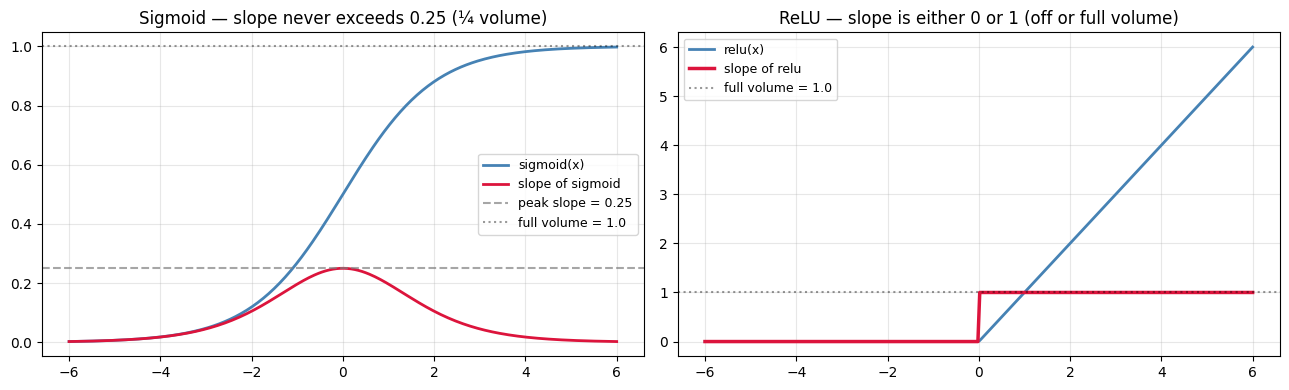

In [ ]:
x = torch.linspace(-6, 6, 300)
sig = torch.sigmoid(x);  sig_slope  = sig * (1 - sig)
relu = torch.relu(x);    relu_slope = (x > 0).float()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, sig, label='sigmoid(x)', color='steelblue', linewidth=2)
axes[0].plot(x, sig_slope, label='slope of sigmoid', color='crimson', linewidth=2)
axes[0].axhline(0.25, color='gray', linestyle='--', alpha=0.7, label='peak slope = 0.25')
axes[0].axhline(1.0,  color='black', linestyle=':', alpha=0.4, label='full volume = 1.0')
axes[0].set_title("Sigmoid — slope never exceeds 0.25 (¼ volume)")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)

axes[1].plot(x, relu, label='relu(x)', color='steelblue', linewidth=2)
axes[1].plot(x, relu_slope, label='slope of relu', color='crimson', linewidth=2.5)
axes[1].axhline(1.0, color='black', linestyle=':', alpha=0.4, label='full volume = 1.0')
axes[1].set_title("ReLU — slope is either 0 or 1 (off or full volume)")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

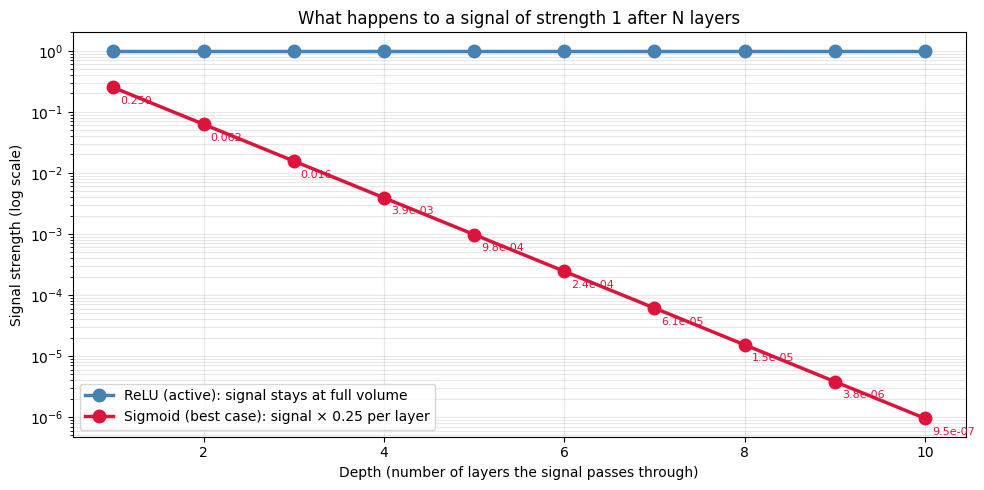

In [ ]:
depths = np.arange(1, 11)
sigmoid_best = 0.25 ** depths               # optimistic: every layer at peak slope
relu_always  = np.ones_like(depths, dtype=float)  # every active ReLU passes it through

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, relu_always,  'o-', color='steelblue', linewidth=2.5,
        markersize=9, label='ReLU (active): signal stays at full volume')
ax.plot(depths, sigmoid_best, 'o-', color='crimson', linewidth=2.5,
        markersize=9, label='Sigmoid (best case): signal × 0.25 per layer')

# Annotate the sigmoid numbers — they're brutal
for d, s in zip(depths, sigmoid_best):
    ax.annotate(f'{s:.1e}' if s < 0.01 else f'{s:.3f}',
                (d, s), xytext=(5, -12), textcoords='offset points',
                fontsize=8, color='crimson')

ax.set_yscale('log')
ax.set_xlabel('Depth (number of layers the signal passes through)')
ax.set_ylabel('Signal strength (log scale)')
ax.set_title("What happens to a signal of strength 1 after N layers")
ax.grid(alpha=0.3, which='both'); ax.legend()
plt.tight_layout(); plt.show()

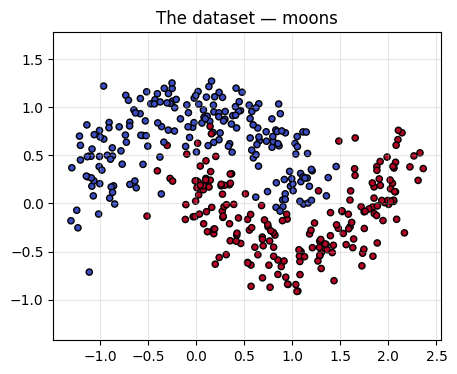

In [ ]:
X, y = make_moons(n_samples=400, noise=0.20, random_state=42)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
plt.title("The dataset — moons"); plt.axis('equal'); plt.grid(alpha=0.3); plt.show()

In [ ]:
#(2, 32),    # layer 0 — closest to input
#(32, 32),   # layer 1
#(32, 32),   # layer 2
#(32, 32),   # layer 3
#(32, 32),   # layer 4
#(32, 32),   # layer 5
#(32, 2),    # layer 6 — output, closest to loss

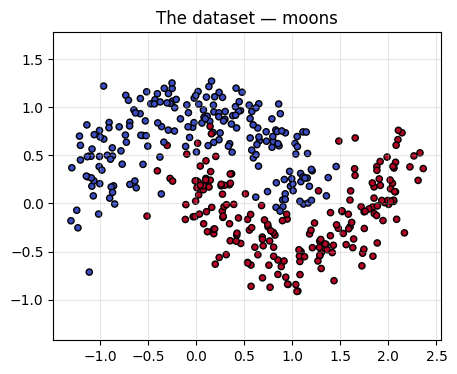

In [ ]:
X, y = make_moons(n_samples=400, noise=0.20, random_state=42)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
plt.title("The dataset — moons"); plt.axis('equal'); plt.grid(alpha=0.3); plt.show()

In [ ]:
import numpy as np

np.unique(y)

array([0, 1])

## Approach 1 of using torch to create a model and train it on the moon dataset

In [ ]:

def fit_moon_with_n_neurons(steps=10):
    torch.manual_seed(3)
    model = nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        #loss = ((model(X_t) - y_t) ** 2).mean()

        loss = nn.BCELoss()(model(X_t).squeeze(), y_t.float())
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(X_t).squeeze().numpy()

In [ ]:
predictions = fit_moon_with_n_neurons()

In [ ]:
y_pred = (predictions > 0.5).astype(int)  # convert probabilities to class labels (0 or 1)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8450


## Approach 2

In [ ]:
class dhyanendra(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(2, 32),    # layer 0 — closest to input
            nn.Linear(32, 32),   # layer 1
            nn.Linear(32, 32),   # layer 2
            nn.Linear(32, 32),   # layer 3
            nn.Linear(32, 32),   # layer 4
            nn.Linear(32, 32),   # layer 5
            nn.Linear(32, 2),    # layer 6 — output, closest to loss
        ])
        self.act = activation_fn

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.act(layer(x))
        return self.layers[-1](x)

In [ ]:
#class dhyanendra(nn.Module):
#    def __init__(self, activation_fn):
#        super().__init__()
#        self.fc1 = nn.Linear(2, 32)
#        self.fc2 = nn.Linear(32, 32)
#        self.fc3 = nn.Linear(32, 32)
#        self.fc4 = nn.Linear(32, 32)
#        self.fc5 = nn.Linear(32, 32)
#        self.fc6 = nn.Linear(32, 32)
#        self.fc7 = nn.Linear(32, 2)
#        self.act = activation_fn

#    def forward(self, x):
#        x = self.act(self.fc1(x))
#        x = self.act(self.fc2(x))
#        x = self.act(self.fc3(x))
#        x = self.act(self.fc4(x))
#        x = self.act(self.fc5(x))
#        x = self.act(self.fc6(x))
#        x = self.fc7(x)
#        return x

In [ ]:
def train_and_track(activation_fn, steps=800, lr=0.1):
    torch.manual_seed(0)                   # same init for fair comparison
    model = dhyanendra(activation_fn)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    grads_per_layer = [[] for _ in range(7)]

    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        losses.append(loss.item())
        for i, layer in enumerate(model.layers):
            grads_per_layer[i].append(layer.weight.grad.norm().item())
        opt.step()

    acc = (model(X_t).argmax(1) == y_t).float().mean().item()
    return losses, grads_per_layer, acc

sig_losses, sig_grads, sig_acc = train_and_track(torch.sigmoid)
relu_losses, relu_grads, relu_acc = train_and_track(torch.relu)

print(f"Sigmoid net: final loss = {sig_losses[-1]:.4f}, accuracy = {sig_acc:.1%}")
print(f"ReLU net:    final loss = {relu_losses[-1]:.4f}, accuracy = {relu_acc:.1%}")

Sigmoid net: final loss = 0.6931, accuracy = 40.5%
ReLU net:    final loss = 0.0694, accuracy = 97.8%


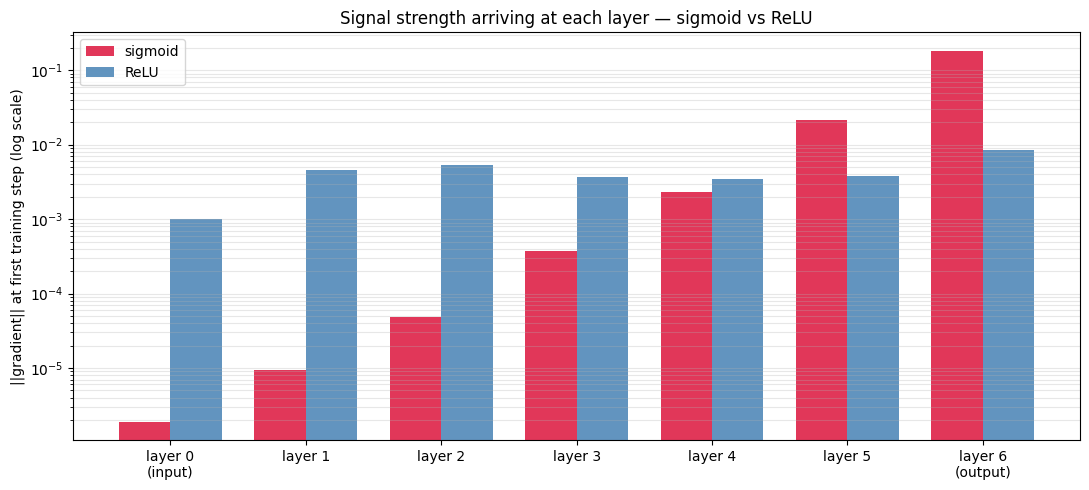


Sigmoid: last-layer grad is 95,427x larger than first-layer grad
ReLU:    last-layer grad is 8.4x larger than first-layer grad


In [ ]:
# Gradient norm at the very first step — cleanest view of "what arrived"
sig_first_step = [g[0] for g in sig_grads]
relu_first_step = [g[0] for g in relu_grads]

layer_idx = np.arange(7)
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(layer_idx - width/2, sig_first_step, width, label='sigmoid',
       color='crimson', alpha=0.85)
ax.bar(layer_idx + width/2, relu_first_step, width, label='ReLU',
       color='steelblue', alpha=0.85)

ax.set_yscale('log')
ax.set_xticks(layer_idx)
ax.set_xticklabels([f'layer {i}\n(input)' if i == 0
                    else f'layer {i}\n(output)' if i == 6
                    else f'layer {i}' for i in layer_idx])
ax.set_ylabel('||gradient|| at first training step (log scale)')
ax.set_title("Signal strength arriving at each layer — sigmoid vs ReLU")
ax.legend(); ax.grid(alpha=0.3, axis='y', which='both')
plt.tight_layout(); plt.show()

print(f"\nSigmoid: last-layer grad is {sig_first_step[-1]/sig_first_step[0]:,.0f}x "
      f"larger than first-layer grad")
print(f"ReLU:    last-layer grad is {relu_first_step[-1]/relu_first_step[0]:.1f}x "
      f"larger than first-layer grad")

# Train NN with just Tensors

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# use mps
# device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


In [ ]:
# Download and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),           # Convert image to tensor (also scales to 0-1)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}  (channels, height, width)")
print(f"Flattened:        {28*28} = 784 input features")
print(f"Classes:          0-9 (10 digits)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 55.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.50MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.08MB/s]


Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])  (channels, height, width)
Flattened:        784 = 784 input features
Classes:          0-9 (10 digits)


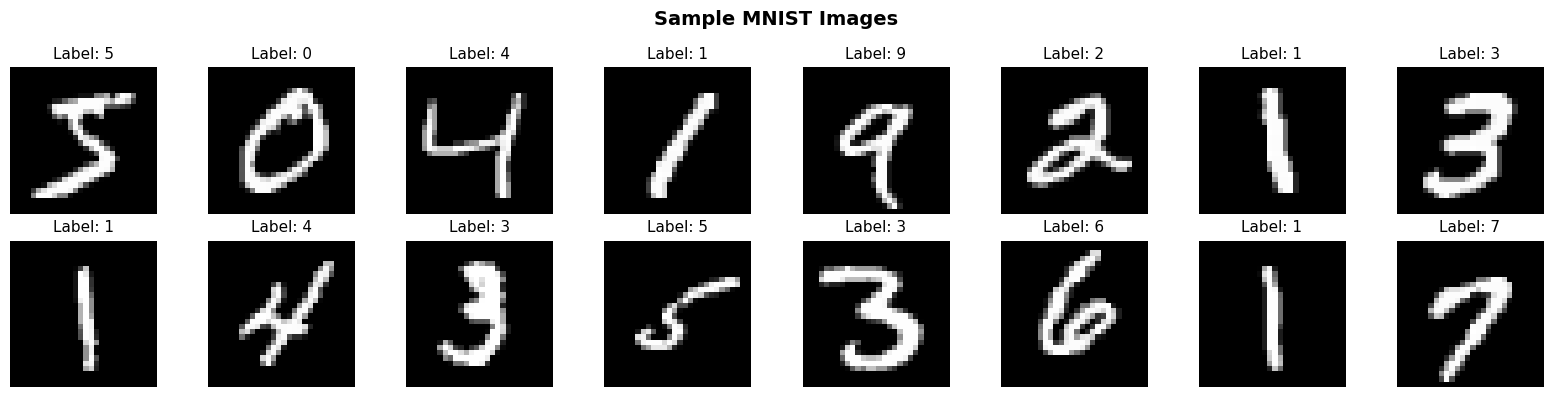

In [ ]:
# Let's look at some examples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=11)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Prepare the FULL dataset as tensors for Stage 1 (manual training)
# We load everything into memory at once for simplicity

X_train = train_dataset.data.float() / 255.0   # Normalize to 0-1
X_train = X_train.view(-1, 784)                 # Flatten: (60000, 28, 28) → (60000, 784)
y_train = train_dataset.targets                  # Labels: (60000,)

X_test = test_dataset.data.float() / 255.0
X_test = X_test.view(-1, 784)
y_test = test_dataset.targets

print(f"X_train shape: {X_train.shape}  — 60,000 images, each flattened to 784 pixels")
print(f"y_train shape: {y_train.shape}  — 60,000 labels (0-9)")
print(f"X_test shape:  {X_test.shape}")

# Show what a flattened image looks like
print(f"\nFirst image as a flat vector (first 20 values):")
print(f"{X_train[0, :20].numpy().round(2)}")
print(f"... (784 values total, mostly 0s because the background is black)")

X_train shape: torch.Size([60000, 784])  — 60,000 images, each flattened to 784 pixels
y_train shape: torch.Size([60000])  — 60,000 labels (0-9)
X_test shape:  torch.Size([10000, 784])

First image as a flat vector (first 20 values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
... (784 values total, mostly 0s because the background is black)


In [ ]:
# First, let's define ReLU ourselves — it's just "keep positive values, zero out negatives"
def relu(x):
    """ReLU activation: if x > 0, keep it. Otherwise, return 0."""
    return torch.max(x, torch.tensor(0.0))

In [ ]:
def init_weights(fan_in, fan_out):
    """Create a weight matrix with small random values."""
    W = torch.randn(fan_in, fan_out) * 0.01
    return W.requires_grad_(True)

def init_bias(size):
    """Create a bias vector initialized to zeros."""
    return torch.zeros(size, requires_grad=True)


W1 = init_weights(784, 256)
b1 = init_bias(256)

W2 = init_weights(256, 128)
b2 = init_bias(128)

W3 = init_weights(128, 64)
b3 = init_bias(64)

W4 = init_weights(64, 10)
b4 = init_bias(10)


params = [W1, b1, W2, b2, W3, b3, W4, b4]

total_params = sum(p.numel() for p in params) #numel gives the total number of elements in the tensor
print(f"Network architecture: 784 → 256 → 128 → 64 → 10")
print(f"\nParameter count per layer:")
print(f"  Layer 1: {W1.numel()} weights + {b1.numel()} biases = {W1.numel() + b1.numel()}")
print(f"  Layer 2: {W2.numel()} weights + {b2.numel()} biases = {W2.numel() + b2.numel()}")
print(f"  Layer 3: {W3.numel()} weights + {b3.numel()} biases = {W3.numel() + b3.numel()}")
print(f"  Layer 4: {W4.numel()} weights + {b4.numel()} biases = {W4.numel() + b4.numel()}")
print(f"\n  Total learnable parameters: {total_params:,}")

Network architecture: 784 → 256 → 128 → 64 → 10

Parameter count per layer:
  Layer 1: 200704 weights + 256 biases = 200960
  Layer 2: 32768 weights + 128 biases = 32896
  Layer 3: 8192 weights + 64 biases = 8256
  Layer 4: 640 weights + 10 biases = 650

  Total learnable parameters: 242,762


In [ ]:
def forward_manual(x):
    """
    Forward pass through our 4-layer network.

    Pattern at each hidden layer:
        1. Linear transform:   z = x @ W + b
        2. ReLU activation:    a = relu(z)

    Output layer has NO activation here — we'll apply softmax inside the loss function.
    (CrossEntropyLoss in PyTorch expects raw logits, not probabilities.)
    """
    # layer 1; shape of x = (batch, 784)


    # Layer 1
    z1 = x @ W1 + b1        # Linear:  (batch, 784) @ (784, 256) → (batch, 256)
    a1 = relu(z1)           # ReLU:    negative values → 0


    # Layer 2
    z2 = a1 @ W2 + b2       # Linear:  (batch, 256) @ (256, 128) → (batch, 128)
    a2 = relu(z2)           # ReLU

        # Layer 3
    z3 = a2 @ W3 + b3       # Linear:  (batch, 128) @ (128, 64) → (batch, 64)
    a3 = relu(z3)           # ReLU

    # Output layer — raw scores (logits), no activation
    logits = a3 @ W4 + b4   # Linear:  (batch, 64) @ (64, 10) → (batch, 10)

    return logits

In [ ]:
# Quick test — does it produce the right shape?
test_input = X_train[:5]  # 5 images
test_output = forward_manual(test_input)
print(f"Input shape:  {test_input.shape}   — 5 images, 784 pixels each")
print(f"Output shape: {test_output.shape}  — 5 images, 10 scores each (one per digit)")
print(f"\nRaw output for first image (logits — NOT probabilities yet):")
print(f"  {test_output[0].detach().numpy().round(3)}")
print(f"  Predicted digit: {test_output[0].argmax().item()}  (just a random guess — untrained!)")

Input shape:  torch.Size([5, 784])   — 5 images, 784 pixels each
Output shape: torch.Size([5, 10])  — 5 images, 10 scores each (one per digit)

Raw output for first image (logits — NOT probabilities yet):
  [ 0.  0. -0.  0. -0. -0.  0. -0.  0. -0.]
  Predicted digit: 0  (just a random guess — untrained!)


In [ ]:
learning_rate = 0.1
epochs = 10

# Cross-entropy loss combines softmax + negative log likelihood
# It's the standard loss for classification tasks
loss_fn = nn.CrossEntropyLoss()

losses_stage1 = []
accuracies_stage1 = []

print("Training with raw tensors + autograd")
print("=" * 55)

start_time = time.time()

for epoch in range(epochs):
    # --- FORWARD PASS (entire dataset at once) ---
    logits = forward_manual(X_train)
    loss = loss_fn(logits, y_train)

    # --- BACKWARD PASS ---
    # This single call computes ALL gradients through the entire network
    # PyTorch traces the computation graph built during forward pass
    # and applies the chain rule automatically
    loss.backward()

    # --- UPDATE WEIGHTS ---
    # Gradient descent: move each parameter in the opposite direction of its gradient
    with torch.no_grad():  # Don't track these operations
        for p in params:
            p -= learning_rate * p.grad  # The actual learning step
            p.grad.zero_()               # Reset gradients for next iteration

    # Track metrics
    train_acc = (logits.argmax(dim=1) == y_train).float().mean().item() * 100
    losses_stage1.append(loss.item())
    accuracies_stage1.append(train_acc)

     # Test accuracy
    with torch.no_grad():
        test_logits = forward_manual(X_test)
        test_acc = (test_logits.argmax(dim=1) == y_test).float().mean().item() * 100

    print(f"  Epoch {epoch+1}/{epochs}  |  Loss: {loss.item():.4f}  |  Train Acc: {train_acc:.1f}%  |  Test Acc: {test_acc:.1f}%")

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f}s — Final test accuracy: {test_acc:.1f}%")

Training with raw tensors + autograd
  Epoch 1/10  |  Loss: 2.3026  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 2/10  |  Loss: 2.3025  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 3/10  |  Loss: 2.3025  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 4/10  |  Loss: 2.3025  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 5/10  |  Loss: 2.3024  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 6/10  |  Loss: 2.3024  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 7/10  |  Loss: 2.3024  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 8/10  |  Loss: 2.3024  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 9/10  |  Loss: 2.3023  |  Train Acc: 11.2%  |  Test Acc: 11.3%
  Epoch 10/10  |  Loss: 2.3023  |  Train Acc: 11.2%  |  Test Acc: 11.3%

Done in 25.0s — Final test accuracy: 11.3%


### Fixing the Training: Mini-batch Gradient Descent
Instead of calculating the gradient for the whole dataset, we will loop through the data in smaller chunks (batches). This is much more efficient and helps the model converge.

In [ ]:
batch_size = 64
learning_rate = 0.1
epochs = 5

# Re-initialize parameters to start fresh
W1 = init_weights(784, 256); b1 = init_bias(256)
W2 = init_weights(256, 128); b2 = init_bias(128)
W3 = init_weights(128, 64);  b3 = init_bias(64)
W4 = init_weights(64, 10);   b4 = init_bias(10)
params = [W1, b1, W2, b2, W3, b3, W4, b4]

print(f"Training with Mini-batches (size {batch_size})...")

for epoch in range(epochs):
    # Shuffle data indices for each epoch
    indices = torch.randperm(X_train.size(0))

    epoch_loss = 0
    for i in range(0, X_train.size(0), batch_size):
        # Get batch
        batch_idx = indices[i:i+batch_size]
        X_batch, y_batch = X_train[batch_idx], y_train[batch_idx]

        # Forward
        logits = forward_manual(X_batch)
        loss = loss_fn(logits, y_batch)

        # Backward
        loss.backward()

        # Update
        with torch.no_grad():
            for p in params:
                p -= learning_rate * p.grad
                p.grad.zero_()

        epoch_loss += loss.item()

    # Check accuracy on test set
    with torch.no_grad():
        test_logits = forward_manual(X_test)
        test_acc = (test_logits.argmax(dim=1) == y_test).float().mean().item() * 100

    print(f"Epoch {epoch+1} | Avg Loss: {epoch_loss/(X_train.size(0)/batch_size):.4f} | Test Acc: {test_acc:.1f}%")

Training with Mini-batches (size 64)...
Epoch 1 | Avg Loss: 2.3028 | Test Acc: 11.3%
Epoch 2 | Avg Loss: 2.1284 | Test Acc: 44.0%
Epoch 3 | Avg Loss: 0.5804 | Test Acc: 90.3%
Epoch 4 | Avg Loss: 0.2223 | Test Acc: 94.9%
Epoch 5 | Avg Loss: 0.1377 | Test Acc: 96.5%


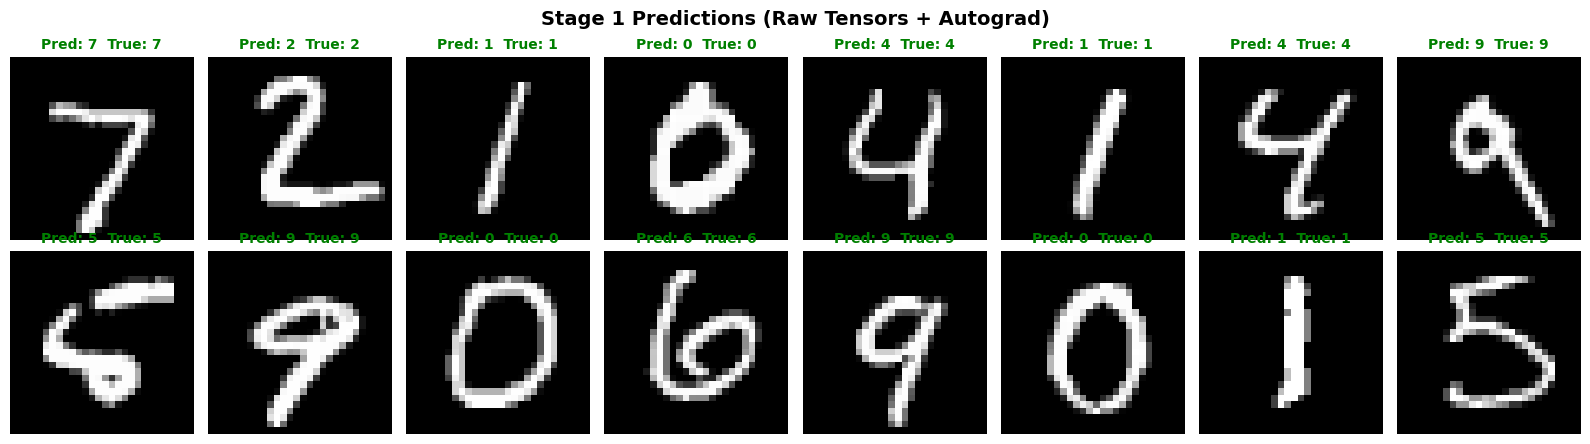

In [ ]:
# Let's see some predictions!

with torch.no_grad():
    test_logits = forward_manual(X_test)
    test_preds = test_logits.argmax(dim=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i, ax in enumerate(axes.flat):
    img = X_test[i].view(28, 28)
    pred = test_preds[i].item()
    true = y_test[i].item()
    ax.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Pred: {pred}  True: {true}', fontsize=10, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Stage 1 Predictions (Raw Tensors + Autograd)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()